# Projet d'Analyse de données



In [60]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from skimpy import skim
import seaborn as sns 
import prince
from statsmodels.graphics.mosaicplot import mosaic
from pandas.plotting import scatter_matrix

%matplotlib inline

# I-  Introduction


## 1) Prise en charge et présentation du jeu de données 

In [2]:
# Liste des variables originales et leurs descriptions
variables = {
    "Date": "Date du jour de la donnée",
    "Service": "Type de service ou train",
    "Gare de départ": "Gare de départ",
    "Gare d'arrivée": "Gare d'arrivée",
    "Durée moyenne du trajet": "Durée moyenne du trajet",
    "Nombre de circulations prévues": "Nombre de circulations prévues",
    "Nombre de trains annulés": "Nombre de trains annulés",
    "Nombre de trains en retard au départ": "Nombre de trains en retard au départ",
    "Retard moyen des trains en retard au départ": "Retard moyen des trains en retard au départ",
    "Retard moyen de tous les trains au départ": "Retard moyen de tous les trains au départ",
    "Nombre de trains en retard à l'arrivée": "Nombre de trains en retard à l'arrivée",
    "Retard moyen des trains en retard à l'arrivée": "Retard moyen des trains en retard à l'arrivée",
    "Retard moyen de tous les trains à l'arrivée": "Retard moyen de tous les trains à l'arrivée",
    "Nombre trains en retard > 15min": "Nombre de trains en retard entre 15 et 30 min",
    "Retard moyen trains en retard > 15 (si liaison concurrencée par vol)": "Retard moyen > 15 min si concurrence aérienne",
    "Nombre trains en retard > 30min": "Nombre de trains en retard entre 30 et 60 min",
    "Nombre trains en retard > 60min": "Nombre de trains en retard de plus de 60 min",
    "Prct retard pour causes externes": "Pourcentage de retard pour causes externes",
    "Prct retard pour cause infrastructure": "Pourcentage de retard pour causes infrastructure",
    "Prct retard pour cause gestion trafic": "Pourcentage de retard pour causes gestion trafic",
    "Prct retard pour cause matériel roulant": "Pourcentage de retard pour causes matériel roulant",
    "Prct retard pour cause gestion en gare et réutilisation de matériel": "Pourcentage de retard pour causes gestion gare / réutilisation matériel",
    "Prct retard pour cause prise en compte voyageurs (affluence": "Pourcentage de retard pour causes affluence voyageurs"
}

# transformer noms plus courts
short_names = {
    "Date": "date",
    "Service": "service",
    "Gare de départ": "dep_station",
    "Gare d'arrivée": "arr_station",
    "Durée moyenne du trajet": "avg_duration",
    "Nombre de circulations prévues": "planned_trains",
    "Nombre de trains annulés": "cancelled_trains",
    "Nombre de trains en retard au départ": "dep_late_trains",
    "Retard moyen des trains en retard au départ": "dep_avg_late",
    "Retard moyen de tous les trains au départ": "dep_avg_all",
    "Nombre de trains en retard à l'arrivée": "arr_late_trains",
    "Retard moyen des trains en retard à l'arrivée": "arr_avg_late",
    "Retard moyen de tous les trains à l'arrivée": "arr_avg_all",
    "Nombre trains en retard > 15min": "late_15",
    "Retard moyen trains en retard > 15 (si liaison concurrencée par vol)": "late_15_air",
    "Nombre trains en retard > 30min": "late_30",
    "Nombre trains en retard > 60min": "late_60",
    "Prct retard pour causes externes": "pct_external",
    "Prct retard pour cause infrastructure": "pct_infra",
    "Prct retard pour cause gestion trafic": "pct_traffic",
    "Prct retard pour cause matériel roulant": "pct_rolling",
    "Prct retard pour cause gestion en gare et réutilisation de matériel": "pct_station",
    "Prct retard pour cause prise en compte voyageurs (affluence": "pct_passengers"
}

# création DataFrame pour affichage 
df_vars = pd.DataFrame({
    "Variables renommées": [short_names[k] for k in variables.keys()],
    "Description": [variables[k] for k in variables.keys()]
})

print("Chaque individu représente un mois, pour lesquels on observe 23 variables")
display(df_vars.style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [dict(selector='th', props=[('text-align', 'left')])]
))


Chaque individu représente un mois, pour lesquels on observe 23 variables


,Variables renommées,Description
0,date,Date du jour de la donnée
1,service,Type de service ou train
2,dep_station,Gare de départ
3,arr_station,Gare d'arrivée
4,avg_duration,Durée moyenne du trajet
5,planned_trains,Nombre de circulations prévues
6,cancelled_trains,Nombre de trains annulés
7,dep_late_trains,Nombre de trains en retard au départ
8,dep_avg_late,Retard moyen des trains en retard au départ
9,dep_avg_all,Retard moyen de tous les trains au départ


In [3]:
data = pd.read_excel('regularite-mensuelle-tgv-aqst_full.ods',engine='odf')
data = data.rename(columns=short_names)

display( 
    data.head().style.background_gradient(cmap='BuPu')
)

c:\Users\alipe\miniconda3\envs\AD_project\Lib\site-packages\pandas\io\formats\style.py:4202: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
c:\Users\alipe\miniconda3\envs\AD_project\Lib\site-packages\pandas\io\formats\style.py:4203: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,date,service,dep_station,arr_station,avg_duration,planned_trains,cancelled_trains,Commentaire annulations,dep_late_trains,dep_avg_late,dep_avg_all,Commentaire retards au départ,arr_late_trains,arr_avg_late,arr_avg_all,Commentaire retards à l'arrivée,late_15,late_15_air,late_30,late_60,pct_external,pct_infra,pct_traffic,pct_rolling,pct_station,pct_passengers,gestions PSH,correspondances),Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141,870,5,nan,289,11.247809,3.693179,nan,147,28.436735,6.511118,nan,110,6.511118,44,8,36.134454,31.092437,10.924370,15.966387,5.042017,0.840336,nan,nan,nan,nan,nan,nan,nan
1,2018-01,National,LE MANS,PARIS MONTPARNASSE,56,406,1,nan,213,8.479969,4.567119,nan,105,18.049048,5.363539,"Ce mois-ci, l'OD a été touchée par les incidents suivants :Le 1er : Tempête Carmen sur la façade Atlantique (52 TGV ; 1079mn)Le 3 : Tempête Eleonor sur l’ouest de la France (35 TGV ; 407mn)Le 5 : Dérangement d’une aiguille en gare de Massy TGV (57 TGV ; 1254mn)Le 7 : Dérangement du poste d’aiguillage de Paris Montparnasse (70 TGV ; 1490mn)Le 12 : Colis suspect en gare de Paris Montparnasse (32 TGV ; 499mn)Le 12 : Incident caténaire en gare de Rennes (26 TGV ; 2188mn)Le 17 : Dérangement du poste d’aiguillage de Paris Montparnasse (26 TGV ; 386mn)Le 17 : Présence d’une personne dans les voies à Ste Luce (11 TGV ; 212mn)Le 26 : Heurt d’une personne au niveau de Tiercé (44 TGV ; 1578mn)",32,5.363539,9,4,20,35,16.666667,16.666667,8.333333,3.333333,nan,nan,nan,nan,nan,nan,nan
2,2018-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166,226,0,nan,21,6.239683,0.286283,nan,19,24.736842,2.938053,nan,11,2.938053,6,1,22.222222,27.777778,16.666667,16.666667,5.555556,11.111111,nan,nan,nan,nan,nan,nan,nan
3,2018-01,National,PARIS MONTPARNASSE,NANTES,124,508,3,nan,71,7.235211,0.734290,nan,58,33.726437,5.292211,nan,39,5.292211,18,8,33.333333,22.222222,16.666667,20.370370,5.555556,1.851852,nan,nan,nan,nan,nan,nan,nan
4,2018-01,National,POITIERS,PARIS MONTPARNASSE,94,472,4,nan,224,6.784673,3.229701,nan,89,14.592697,4.882372,nan,42,4.882372,10,0,15.789474,45.614035,19.298246,15.789474,1.754386,1.754386,nan,nan,nan,nan,nan,nan,nan


In [4]:
data['moy_retard_train_deja_retard'] = np.where(
    data['dep_late_trains'] > 0, 
    (data['dep_avg_all'] * data['planned_trains']) / data['dep_late_trains'], 
    0  # Valeur par défaut si aucun train n'est en retard
)

In [5]:
data.dtypes

date                                   str
service                                str
dep_station                         object
arr_station                         object
avg_duration                         int64
planned_trains                       int64
cancelled_trains                     int64
Commentaire annulations            float64
dep_late_trains                      int64
dep_avg_late                       float64
dep_avg_all                        float64
Commentaire retards au départ      float64
arr_late_trains                      int64
arr_avg_late                       float64
arr_avg_all                        float64
Commentaire retards à l'arrivée        str
late_15                             object
late_15_air                         object
late_30                             object
late_60                             object
pct_external                        object
pct_infra                           object
pct_traffic                         object
pct_rolling

In [19]:
cols_to_drop = [
    c for c in data.columns 
    if c.startswith("Commentaire") 
    or " gestions PSH" in c 
    or "correspondances)" in c
    or c.startswith("Unnamed") 
]
data = data.drop(columns=cols_to_drop)
data = data.dropna()
display(
    data.head().style.background_gradient(cmap="BuPu")
)
len(data)

data['date'] = data['date'].astype('category')
data['service'] = data['service'].astype('category')
data['dep_station'] = data['dep_station'].astype('category')
data['arr_station'] = data['arr_station'].astype('category')
skim(data)

,date,service,dep_station,arr_station,avg_duration,planned_trains,cancelled_trains,dep_late_trains,dep_avg_late,dep_avg_all,arr_late_trains,arr_avg_late,arr_avg_all,late_15,late_15_air,late_30,late_60,pct_external,pct_infra,pct_traffic,pct_rolling,pct_station,pct_passengers,moy_retard_train_deja_retard
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141,870,5,289,11.247809,3.693179,147,28.436735,6.511118,110,6.511118,44,8,36.134454,31.092437,10.924370,15.966387,5.042017,0.840336,11.117875
1,2018-01,National,LE MANS,PARIS MONTPARNASSE,56,406,1,213,8.479969,4.567119,105,18.049048,5.363539,32,5.363539,9,4,20,35,16.666667,16.666667,8.333333,3.333333,8.705401
2,2018-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166,226,0,21,6.239683,0.286283,19,24.736842,2.938053,11,2.938053,6,1,22.222222,27.777778,16.666667,16.666667,5.555556,11.111111,3.080952
3,2018-01,National,PARIS MONTPARNASSE,NANTES,124,508,3,71,7.235211,0.734290,58,33.726437,5.292211,39,5.292211,18,8,33.333333,22.222222,16.666667,20.370370,5.555556,1.851852,5.253796
4,2018-01,National,POITIERS,PARIS MONTPARNASSE,94,472,4,224,6.784673,3.229701,89,14.592697,4.882372,42,4.882372,10,0,15.789474,45.614035,19.298246,15.789474,1.754386,1.754386,6.805441


╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types               Categories                                        │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓ ┏━━━━━━━━━━━━━━━━━━━━━━━┓                                │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃ ┃ Categorical Variables ┃                                │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩ ┡━━━━━━━━━━━━━━━━━━━━━━━┩                                │
│ │ Number of rows    │ 11824  │ │ float64     │ 8     │ │ date                  │                                │
│ │ Number of columns │ 17     │ │ int64       │ 5     │ │ service               │                                │
│ └───────────────────┴────────┘ │ category    │ 4     │ │ dep_station           │                                │
│                                └─────────────┴───────┘ │ arr_station           │                                │
│                                                        └───────────────────────┘                                │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column                 ┃ NA  ┃ NA %  ┃ mean   ┃ sd     ┃ p0      ┃ p25    ┃ p50   ┃ p75   ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │      avg_duration      │   0 │     0 │  170.4 │  87.69 │       0 │     99 │   163 │   223 │   786 │  ▇▇▂   │  │
│ │     planned_trains     │   0 │     0 │  270.9 │    183 │       0 │    150 │   229 │   359 │  1100 │  ▇▇▃▁  │  │
│ │    cancelled_trains    │   0 │     0 │  8.654 │  22.64 │       0 │      0 │     2 │     7 │   297 │   ▇    │  │
│ │    dep_late_trains     │   0 │     0 │  86.04 │  88.66 │       0 │     21 │    52 │   126 │   596 │  ▇▂▁   │  │
│ │      dep_avg_late      │   0 │     0 │  12.26 │   11.8 │       0 │  6.142 │ 10.33 │  15.7 │ 316.2 │   ▇    │  │
│ │      dep_avg_all       │   0 │     0 │  3.121 │  5.155 │  -229.3 │  1.201 │ 2.313 │  3.93 │   115 │     ▇  │  │
│ │    arr_late_trains     │   0 │     0 │  37.31 │  31.04 │       0 │     15 │    29 │    51 │   376 │   ▇▁   │  │
│ │      arr_avg_late      │   0 │     0 │  35.08 │  15.59 │  -40.11 │  25.69 │  33.4 │ 42.37 │ 299.6 │   ▁▇   │  │
│ │      arr_avg_all       │   0 │     0 │  6.025 │  6.988 │  -472.6 │  3.384 │ 5.332 │ 8.064 │    92 │      ▇ │  │
│ │      pct_rolling       │   0 │     0 │  18.88 │  13.59 │       0 │     10 │ 17.03 │ 25.36 │   100 │  ▇▇▁   │  │
│ │      pct_station       │   0 │     0 │  7.662 │  8.453 │       0 │      0 │ 5.882 │ 11.32 │   100 │   ▇▁   │  │
│ │     pct_passengers     │   0 │     0 │  7.885 │   9.79 │       0 │      0 │ 5.263 │ 11.54 │   100 │   ▇▁   │  │
│ │ moy_retard_train_deja_ │   0 │     0 │  11.72 │  14.75 │  -764.2 │  5.702 │ 9.666 │ 14.98 │ 316.1 │     ▇  │  │
│ │         retard         │     │       │        │        │         │        │       │       │       │        │  │
│ └────────────────────────┴─────┴───────┴────────┴────────┴─────────┴────────┴───────┴───────┴───────┴────────┘  │
│                                                    category                                                     │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓  │
│ ┃ column                           ┃ NA        ┃ NA %           ┃ ordered               ┃ unique             ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩  │
│ │               date               │         0 │              0 │ False                 │                 96 │  │
│ │             service              │         0 │      

## 2) Exploration élémentaire : analyse descriptive

### a) Analyse descriptive unidimensionnelle

#### i) Familiarisation et exploration des données

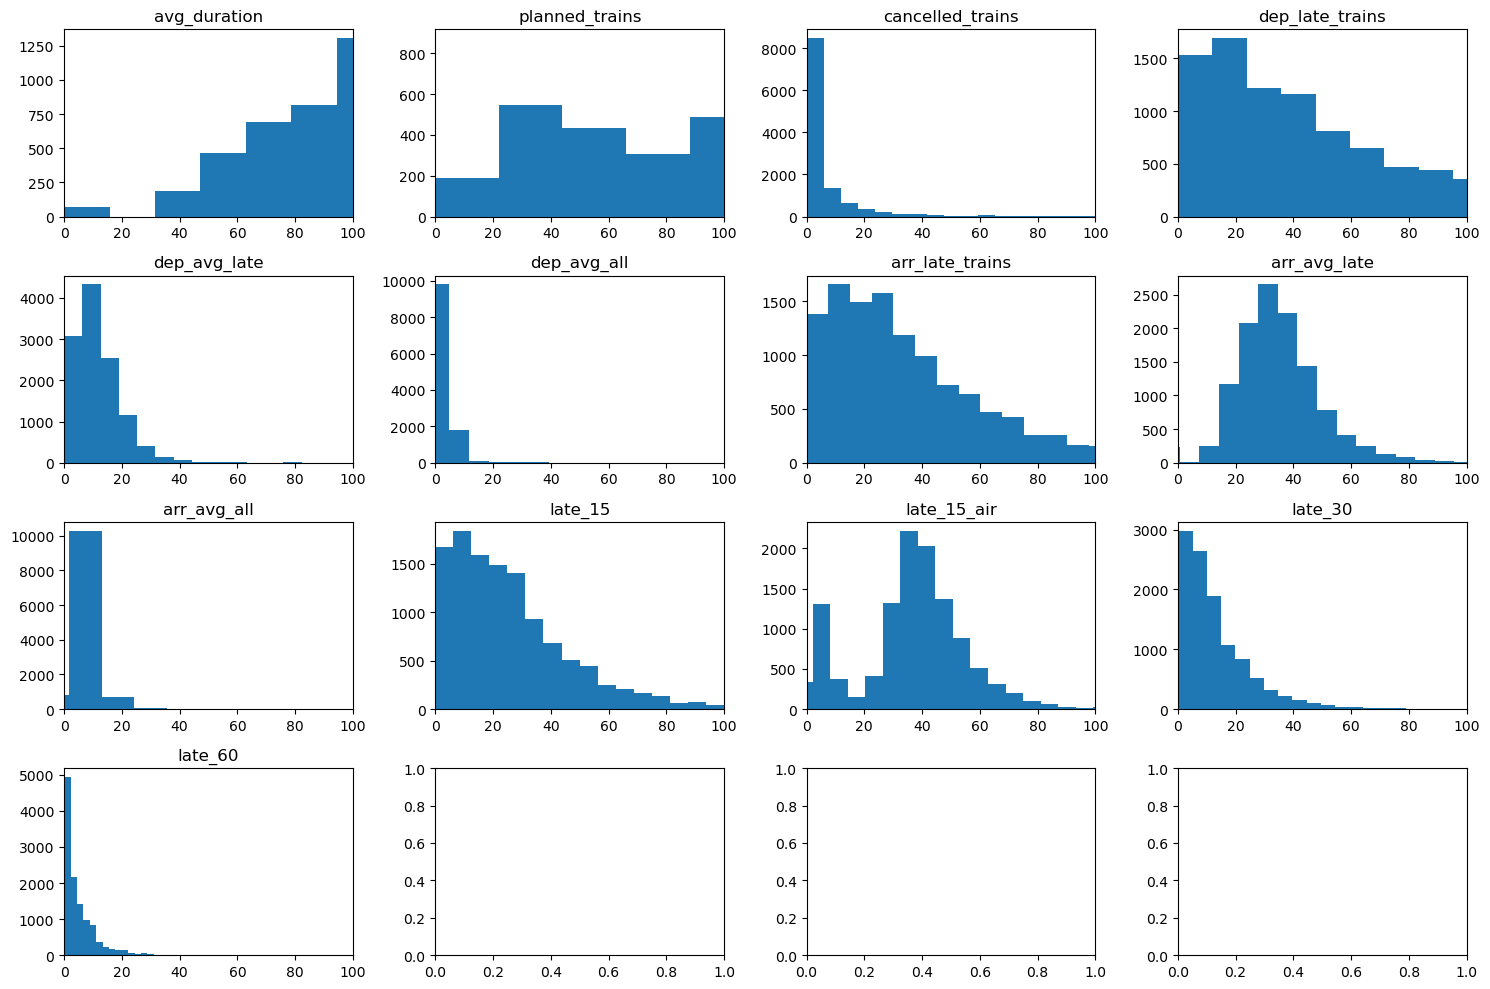

In [21]:
fig, axes = plt.subplots(4, 4, figsize=(15, 10))

columns = ["avg_duration", "planned_trains", "cancelled_trains","dep_late_trains", "dep_avg_late", "dep_avg_all", "arr_late_trains", "arr_avg_late", "arr_avg_all", "late_15", "late_15_air", "late_30", "late_60"]

axes_flat = axes.flatten()

for i, col in enumerate(columns):
    axes_flat[i].set_xlim(0, 100)
    series_to_plot = pd.to_numeric(data[col], errors='coerce').dropna()
    axes_flat[i].hist(series_to_plot, bins=50)
    axes_flat[i].set_title(col)


plt.tight_layout()
plt.show()

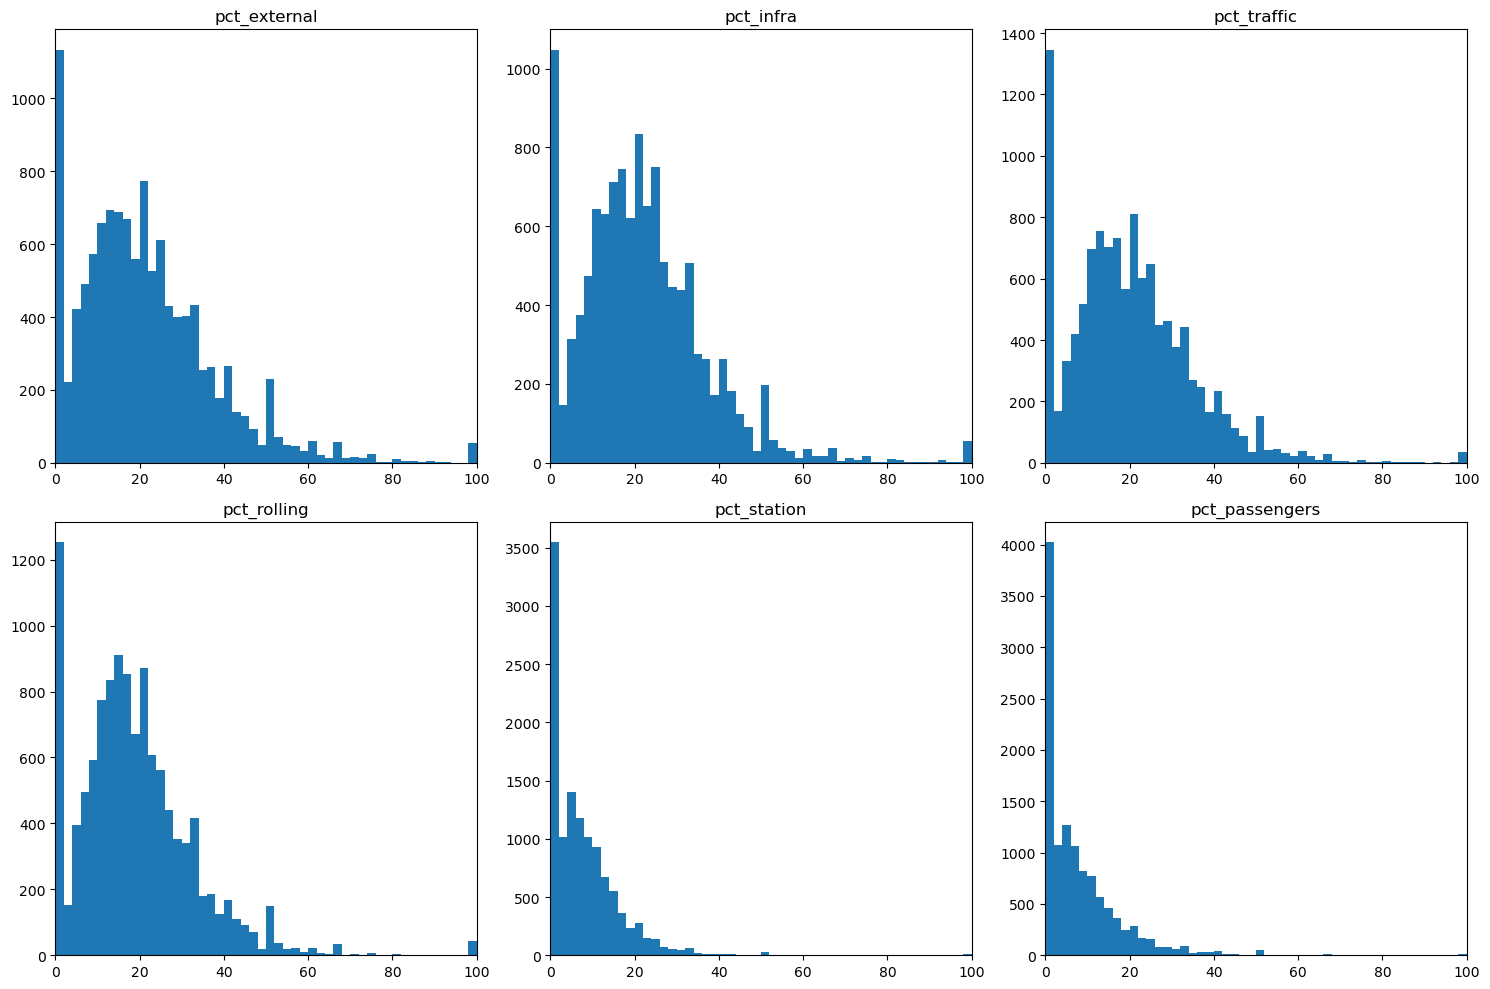

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

columns = ["pct_external", "pct_infra", "pct_traffic","pct_rolling", "pct_station", "pct_passengers"]
axes_flat = axes.flatten()

for i, col in enumerate(columns):
    axes_flat[i].set_xlim(0, 100)
    series_to_plot = pd.to_numeric(data[col], errors='coerce').dropna()
    axes_flat[i].hist(series_to_plot, bins=50)
    axes_flat[i].set_title(col)


plt.tight_layout()
plt.show()

In [9]:
# histogramme des 4 différents temps de retard
#A FAIRE

#### ii) En moyenne, une cause est-elle à l'origne de plus de retard que les autres causes ?

In [24]:
#calcule le % moyen de retard pour causes externes
series_to_plot = pd.to_numeric(data['pct_external'], errors='coerce').dropna()
external_mean = series_to_plot.mean()
print(f"Pourcentage moyen de retard pour causes externes: {external_mean:.2f}%")

#calcule le % moyen de retard pour causes infrastruture
series_to_plot = pd.to_numeric(data['pct_infra'], errors='coerce').dropna()
infrastruture_mean = series_to_plot.mean()
print(f"Pourcentage moyen de retard pour causes infrastruture: {infrastruture_mean:.2f}%")

#calcule le % moyen de retard pour causes gestion traffic
series_to_plot = pd.to_numeric(data['pct_traffic'], errors='coerce').dropna()
traffic_mean = series_to_plot.mean()
print(f"Pourcentage moyen de retard pour causes gestion traffic: {traffic_mean:.2f}%")

#calcule le % moyen de retard pour causes matériel roulant
series_to_plot = pd.to_numeric(data['pct_rolling'], errors='coerce').dropna()
rolling_mean = series_to_plot.mean()
print(f"Pourcentage moyen de retard pour causes matériel roulant: {rolling_mean:.2f}%")

#calcule le % moyen de retard pour causes gestion gare / réutilisation matériel
series_to_plot = pd.to_numeric(data['pct_station'], errors='coerce').dropna()
station_mean = series_to_plot.mean()
print(f"Pourcentage moyen de retard pour causes gestion gare / réutilisation matériel: {station_mean:.2f}%")

#calcule le % moyen de retard pour causes prise en compte voyageurs (affluence)
series_to_plot = pd.to_numeric(data['pct_passengers'], errors='coerce').dropna()
passengers_mean = series_to_plot.mean()
print(f"Pourcentage moyen de retard pour causes prise en compte voyageurs (affluence): {passengers_mean:.2f}%")

Pourcentage moyen de retard pour causes externes: 21.41%
Pourcentage moyen de retard pour causes infrastruture: 21.84%
Pourcentage moyen de retard pour causes gestion traffic: 20.33%
Pourcentage moyen de retard pour causes matériel roulant: 18.88%
Pourcentage moyen de retard pour causes gestion gare / réutilisation matériel: 7.66%
Pourcentage moyen de retard pour causes prise en compte voyageurs (affluence): 7.89%


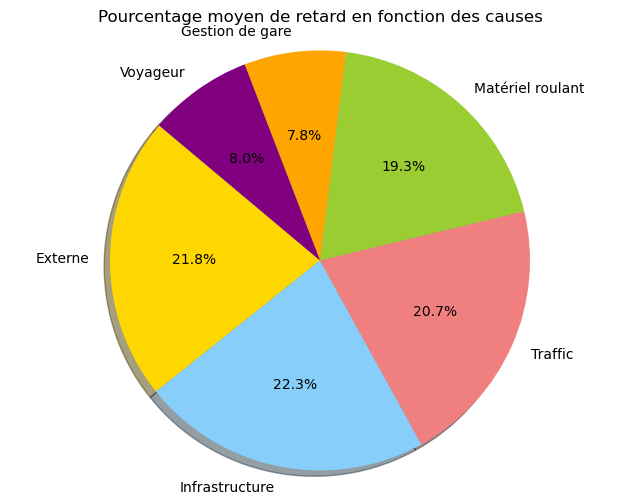

In [25]:
causes = ['Externe', 'Infrastructure', 'Traffic', 'Matériel roulant', 'Gestion de gare','Voyageur']
tailles = [external_mean, infrastruture_mean, traffic_mean, rolling_mean, station_mean,passengers_mean]  # Les parts (en pourcentage ou valeurs brutes)
couleurs = ['gold', 'lightskyblue', 'lightcoral', 'yellowgreen','orange','purple']
#explode = (0.1, 0, 0, 0,0,0)  # On "extrait" la première part (Externe) pour l'effet visuel

plt.figure(figsize=(8, 6))
plt.pie(tailles, 
        labels=causes, 
       #explode=explode,
        colors=couleurs,
        autopct='%1.1f%%', # Affiche le pourcentage avec une décimale
        shadow=True, 
        startangle=140) # Oriente le début du cercle

# 3. Personnalisation
plt.title("Pourcentage moyen de retard en fonction des causes")
plt.axis('equal')  # Assure que le camembert est bien un cercle et non une ellipse

# 4. Affichage
plt.show()

<div style="border:2px solid black; padding:10px;">
Réponse : On ne constante pas de différence du pourcentage de retard significative pour une cause particulière.
</dire

#### iii) Quels sont les trajets annulant le plus de trains ?

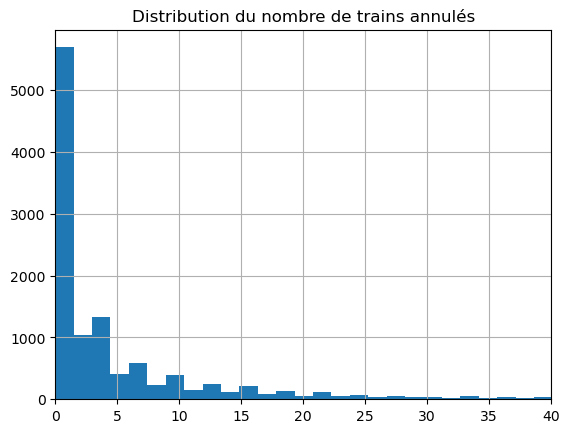

In [31]:
data["cancelled_trains"].hist(bins=200)
plt.xlim(0, 40)
plt.title("Distribution du nombre de trains annulés")
plt.show()

In [41]:
bcp_trains_annules = data[data["cancelled_trains"] > 260]

# Afficher les résultats
for index, row in bcp_trains_annules.iterrows():
    print(f"Alerte : {row['dep_station']} - {row['arr_station']} - {row['date']} a annulé {row['cancelled_trains']} trains.")

Alerte : BORDEAUX ST JEAN - PARIS MONTPARNASSE - 2018-04 a annulé 279 trains.
Alerte : PARIS MONTPARNASSE - BORDEAUX ST JEAN - 2018-05 a annulé 266 trains.
Alerte : PARIS MONTPARNASSE - BORDEAUX ST JEAN - 2021-04 a annulé 274 trains.
Alerte : BORDEAUX ST JEAN - PARIS MONTPARNASSE - 2021-04 a annulé 288 trains.
Alerte : RENNES - PARIS MONTPARNASSE - 2021-04 a annulé 268 trains.
Alerte : PARIS MONTPARNASSE - BORDEAUX ST JEAN - 2023-03 a annulé 277 trains.
Alerte : BORDEAUX ST JEAN - PARIS MONTPARNASSE - 2023-03 a annulé 297 trains.


On remarque qu'il y a certaines lignes qui ont annulés énormément de trains (en moyenne 10 par jours). Cependant, ce résultat n'est pas significatif car tous ces trajets sont reliés à Paris Montparnasse, or c'est la plus grande gare de France. On va donc regarder ce résultat en proportion par rapport au nombre total de trains prévus.

In [45]:
bcp_trains_annules = data[(data["planned_trains"] > 0) & 
                          ((data["cancelled_trains"] / data["planned_trains"]) > 0.6)]
# Afficher les résultats
for index, row in bcp_trains_annules.iterrows():
    print(f"Alerte : {row['dep_station']} - {row['arr_station']} - {row['date']} a annulé {(row['cancelled_trains']/row['planned_trains'])*100} % trains.")

Alerte : MADRID - MARSEILLE ST CHARLES - 2018-04 a annulé 70.83333333333334 % trains.
Alerte : MARSEILLE ST CHARLES - MADRID - 2018-04 a annulé 69.56521739130434 % trains.
Alerte : NANCY - PARIS EST - 2020-04 a annulé 81.48148148148148 % trains.
Alerte : PARIS MONTPARNASSE - POITIERS - 2020-04 a annulé 68.08510638297872 % trains.
Alerte : PARIS MONTPARNASSE - ST PIERRE DES CORPS - 2020-04 a annulé 81.08108108108108 % trains.
Alerte : STRASBOURG - PARIS EST - 2020-04 a annulé 92.6829268292683 % trains.
Alerte : PARIS LYON - AVIGNON TGV - 2020-04 a annulé 67.85714285714286 % trains.
Alerte : STUTTGART - PARIS EST - 2020-04 a annulé 87.5 % trains.
Alerte : ZURICH - PARIS LYON - 2020-04 a annulé 77.77777777777779 % trains.
Alerte : ST PIERRE DES CORPS - PARIS MONTPARNASSE - 2020-04 a annulé 78.37837837837837 % trains.
Alerte : REIMS - PARIS EST - 2020-04 a annulé 83.33333333333334 % trains.
Alerte : PARIS EST - STRASBOURG - 2020-04 a annulé 87.5 % trains.
Alerte : AIX EN PROVENCE TGV - PAR

<div style="border:2px solid black; padding:10px;">
 Plus de 1400 trajets (lignes dans les données) ont annulés 7 trains.
Au delà de 15 annulations très peu de trains sont réannulés, sauf quelques cas particuliers (qui ont annulés 39 trains).
On constate que les trajets annulant plus de 30 trains vont par paire. 
Tout les trajets ayant annulés plus de 30 trains partent ou arrivent à paris montparnasse. Eventuels travaux a montparnasse ? Plus grand nombre de trains donc plus d'annulations ?.
 </div>

### Existe t-il une corrélation entre le retard d'un aller et de son retour ?

In [47]:
proportion_retard = (data['arr_late_trains']+data['cancelled_trains']) / data['planned_trains']

bins = [-0.01, 0.05, 0.15, 0.40, 1.0]
labels = ['Jamais', 'Rarement', 'Régulièrement', 'Souvent']

data['retard'] = pd.cut(proportion_retard, bins=bins, labels=labels)

print(data['retard'].value_counts())

retard
Rarement         5459
Régulièrement    5436
Souvent           552
Jamais            304
Name: count, dtype: int64


### Rapport entre nombre de circulations et nombres de retards / d'annulations.

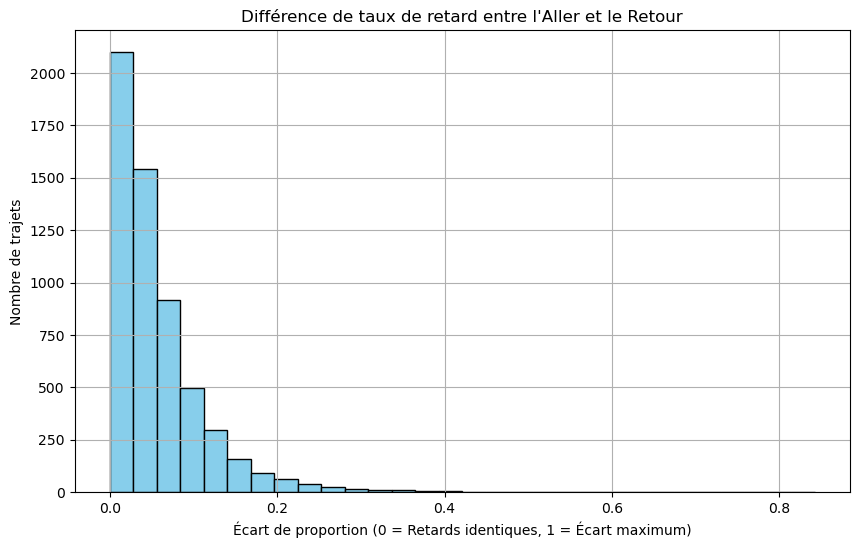

Écart moyen entre l'aller et le retour : 0.0574


In [55]:
# Calcul de la proportion de retard si ce n'est pas déjà fait
data['proportion_retard'] = (data['arr_late_trains'] + data['cancelled_trains']) / data['planned_trains'].replace(0, np.nan)

df_etude = data.copy()

# Création d'un identifiant de trajet unique (Aller et Retour confondus)
# On trie les gares par ordre alphabétique pour que A->B et B->A donnent la même clé
df_etude['trajet_key'] = df_etude.apply(lambda x: "-".join(sorted([str(x['dep_station']), str(x['arr_station'])])), axis=1)

# On ajoute la date pour isoler les trajets du même jour/mois
df_etude['unique_id'] = df_etude['trajet_key'] + "_" + df_etude['date'].astype(str)

# On groupe par trajet et date, puis on calcule l'écart (max - min ou premier - dernier)
# L'idée est de voir si l'écart est proche de 0 (retards similaires) ou élevé
diff_retards = df_etude.groupby('unique_id')['proportion_retard'].agg(lambda x: x.max() - x.min() if len(x) == 2 else np.nan)

# On retire les trajets qui n'ont pas de retour correspondant (les NaN)
diff_retards = diff_retards.dropna()


plt.figure(figsize=(10, 6))
diff_retards.hist(bins=30, color='skyblue', edgecolor='black')

plt.title("Différence de taux de retard entre l'Aller et le Retour")
plt.xlabel("Écart de proportion (0 = Retards identiques, 1 = Écart maximum)")
plt.ylabel("Nombre de trajets")
plt.show()

print(f"Écart moyen entre l'aller et le retour : {diff_retards.mean():.4f}")


<Figure size 1200x800 with 0 Axes>

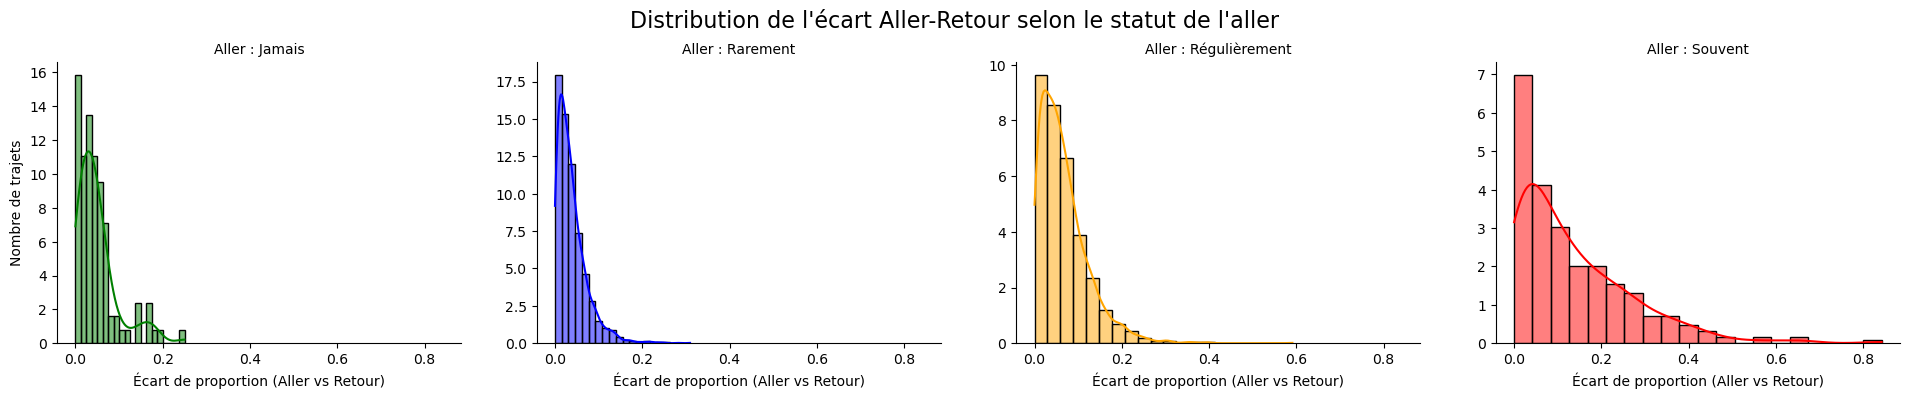

In [56]:
df_etude = df_etude.sort_values(['unique_id', 'dep_station'])


resume_trajets = df_etude.groupby('unique_id').agg({
    'retard': 'first', 
    'proportion_retard': lambda x: x.max() - x.min() if len(x) == 2 else np.nan
}).dropna()

resume_trajets.columns = ['statut_aller', 'ecart_proportion']

plt.figure(figsize=(12, 8))


palette = {'Jamais': 'green', 'Rarement': 'blue', 'Régulièrement': 'orange', 'Souvent': 'red'}

g = sns.FacetGrid(resume_trajets, col="statut_aller", col_order=labels, 
                  hue="statut_aller", palette=palette, height=4, aspect=1.2, sharey=False)

g.map(sns.histplot, "ecart_proportion", bins=20, kde=True, stat="density", common_norm=False)
g.set_axis_labels("Écart de proportion (Aller vs Retour)", "Nombre de trajets")
g.set_titles("Aller : {col_name}")
plt.subplots_adjust(top=0.85)
g.fig.suptitle("Distribution de l'écart Aller-Retour selon le statut de l'aller", fontsize=16)

plt.show()

<div style="border:2px solid black; padding:10px;">
En étudiant les graphs ci dessus, on constate que les correspondances régulierements en retard dans un sens le sont aussi dans l'autre, puisque la différence des 2 est centrée en zéro et est bien proche du centre. Cela signifie que les lignes ou l'on constate des retards réguliers sont impactés dans les 2 sens. 
En regardant le boxplot, on voit tout de même une certaines tendance: les trains en retard régulierement sont plus favorable à avoir leur complémentaire dans l'autre sens aussi en retard régulierement. A moindre echelle, on observe la même chose pour les trains jamais, souvent et toujours en retard. 
 </div>

In [61]:
ordre = ['Jamais', 'Rarement', 'Régulièrement', 'Souvent']
merged['label_aller'] = pd.Categorical(merged['label_aller'], categories=ordre, ordered=True)
merged['label_retour'] = pd.Categorical(merged['label_retour'], categories=ordre, ordered=True)

plt.figure(figsize=(15, 10))

props = lambda key: {'color': 'r' if 'Souvent' in key[1] else 'orange' if 'Régulièrement' in key[1] else 'b' if 'Rarement' in key[1] else 'g'}

labelizer = lambda k: ""

mosaic(merged, ['label_aller', 'label_retour'], 
       title="Corrélation des statuts de retard : Aller vs Retour",
       properties=props,
       labelizer=labelizer)

plt.xlabel("Statut du train ALLER")
plt.ylabel("Statut du train RETOUR")
plt.show()

NameError: name 'merged' is not defined

## Analyse descriptive bidimensionnelles


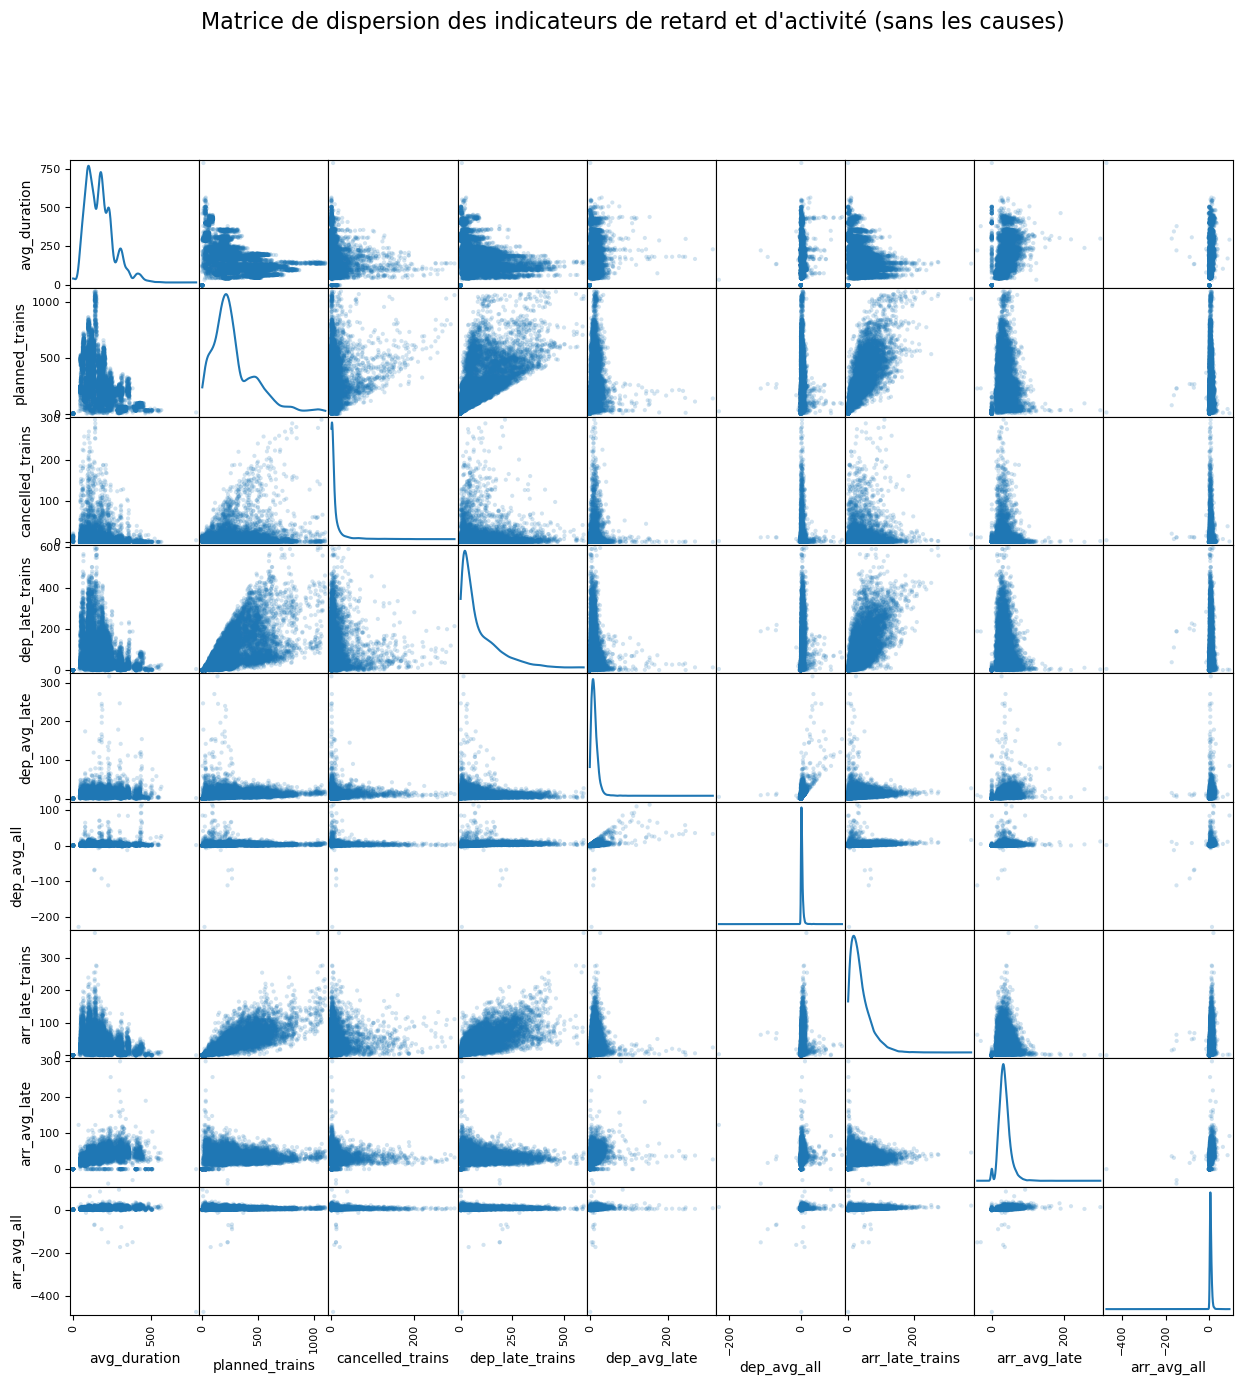

In [28]:
scatter_matrix(data[["avg_duration", "planned_trains", "cancelled_trains","dep_late_trains", "dep_avg_late", "dep_avg_all", "arr_late_trains", "arr_avg_late", "arr_avg_all", "late_15", "late_15_air", "late_30", "late_60"]], alpha=0.2, 
               figsize=(15, 15), diagonal='kde')
plt.suptitle("Matrice de dispersion des indicateurs de retard et d'activité (sans les causes)", fontsize=16)
plt.show()

### 3. Existe t-il une corrélation entre les causes de retard des trains et les durées de retard des trains ?

On construit plusieurs dataset pour mener nos études plus facilement.

In [17]:
#dataset des variables quantitatives
data_quanti = data[[
    "avg_duration", "planned_trains", "cancelled_trains", "dep_late_trains",
    "dep_avg_late", "dep_avg_all", "arr_late_trains", "arr_avg_late",
    "arr_avg_all", "late_15", "late_15_air", "late_30", "late_60",
    "pct_external", "pct_infra", "pct_traffic", "pct_rolling",
    "pct_station", "pct_passengers"
]]

#dataset avec les 6 différentes causes de retard et les 4 différentes durées de retard
data_cause_duree = data[[ "late_15", "late_15_air", "late_30", "late_60", "pct_external", "pct_infra", "pct_traffic", "pct_rolling",
    "pct_station", "pct_passengers"]]
#ATTENTION A AJOUTER LATE_5 SI ON CONSTRUIT CETTE VARIABLE

#dataset comprenant les temps de trajet des trains et les temps de retard
data_temps_de_trajet_vs_retard= data[["dep_late_trains",
    "dep_avg_late", "dep_avg_all", "arr_late_trains", "arr_avg_late",
    "arr_avg_all"]]

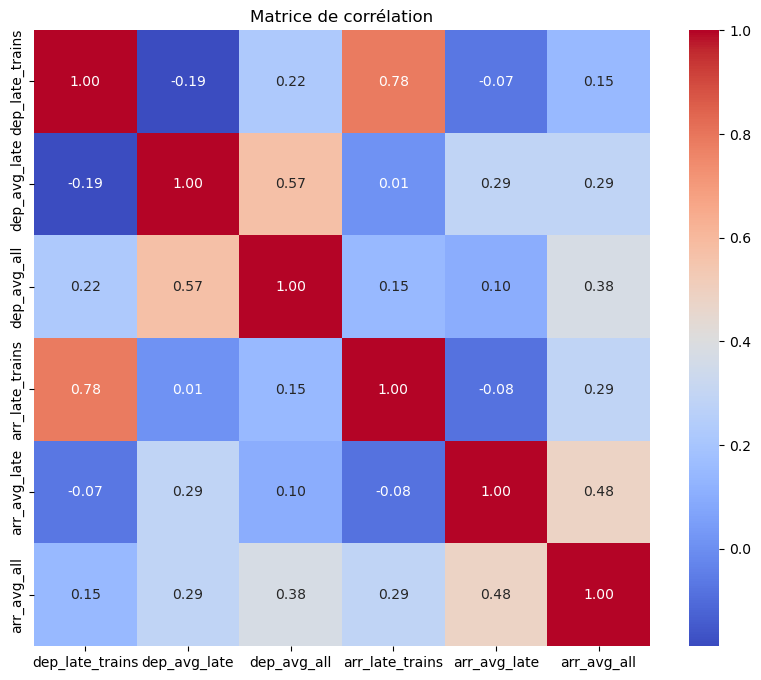

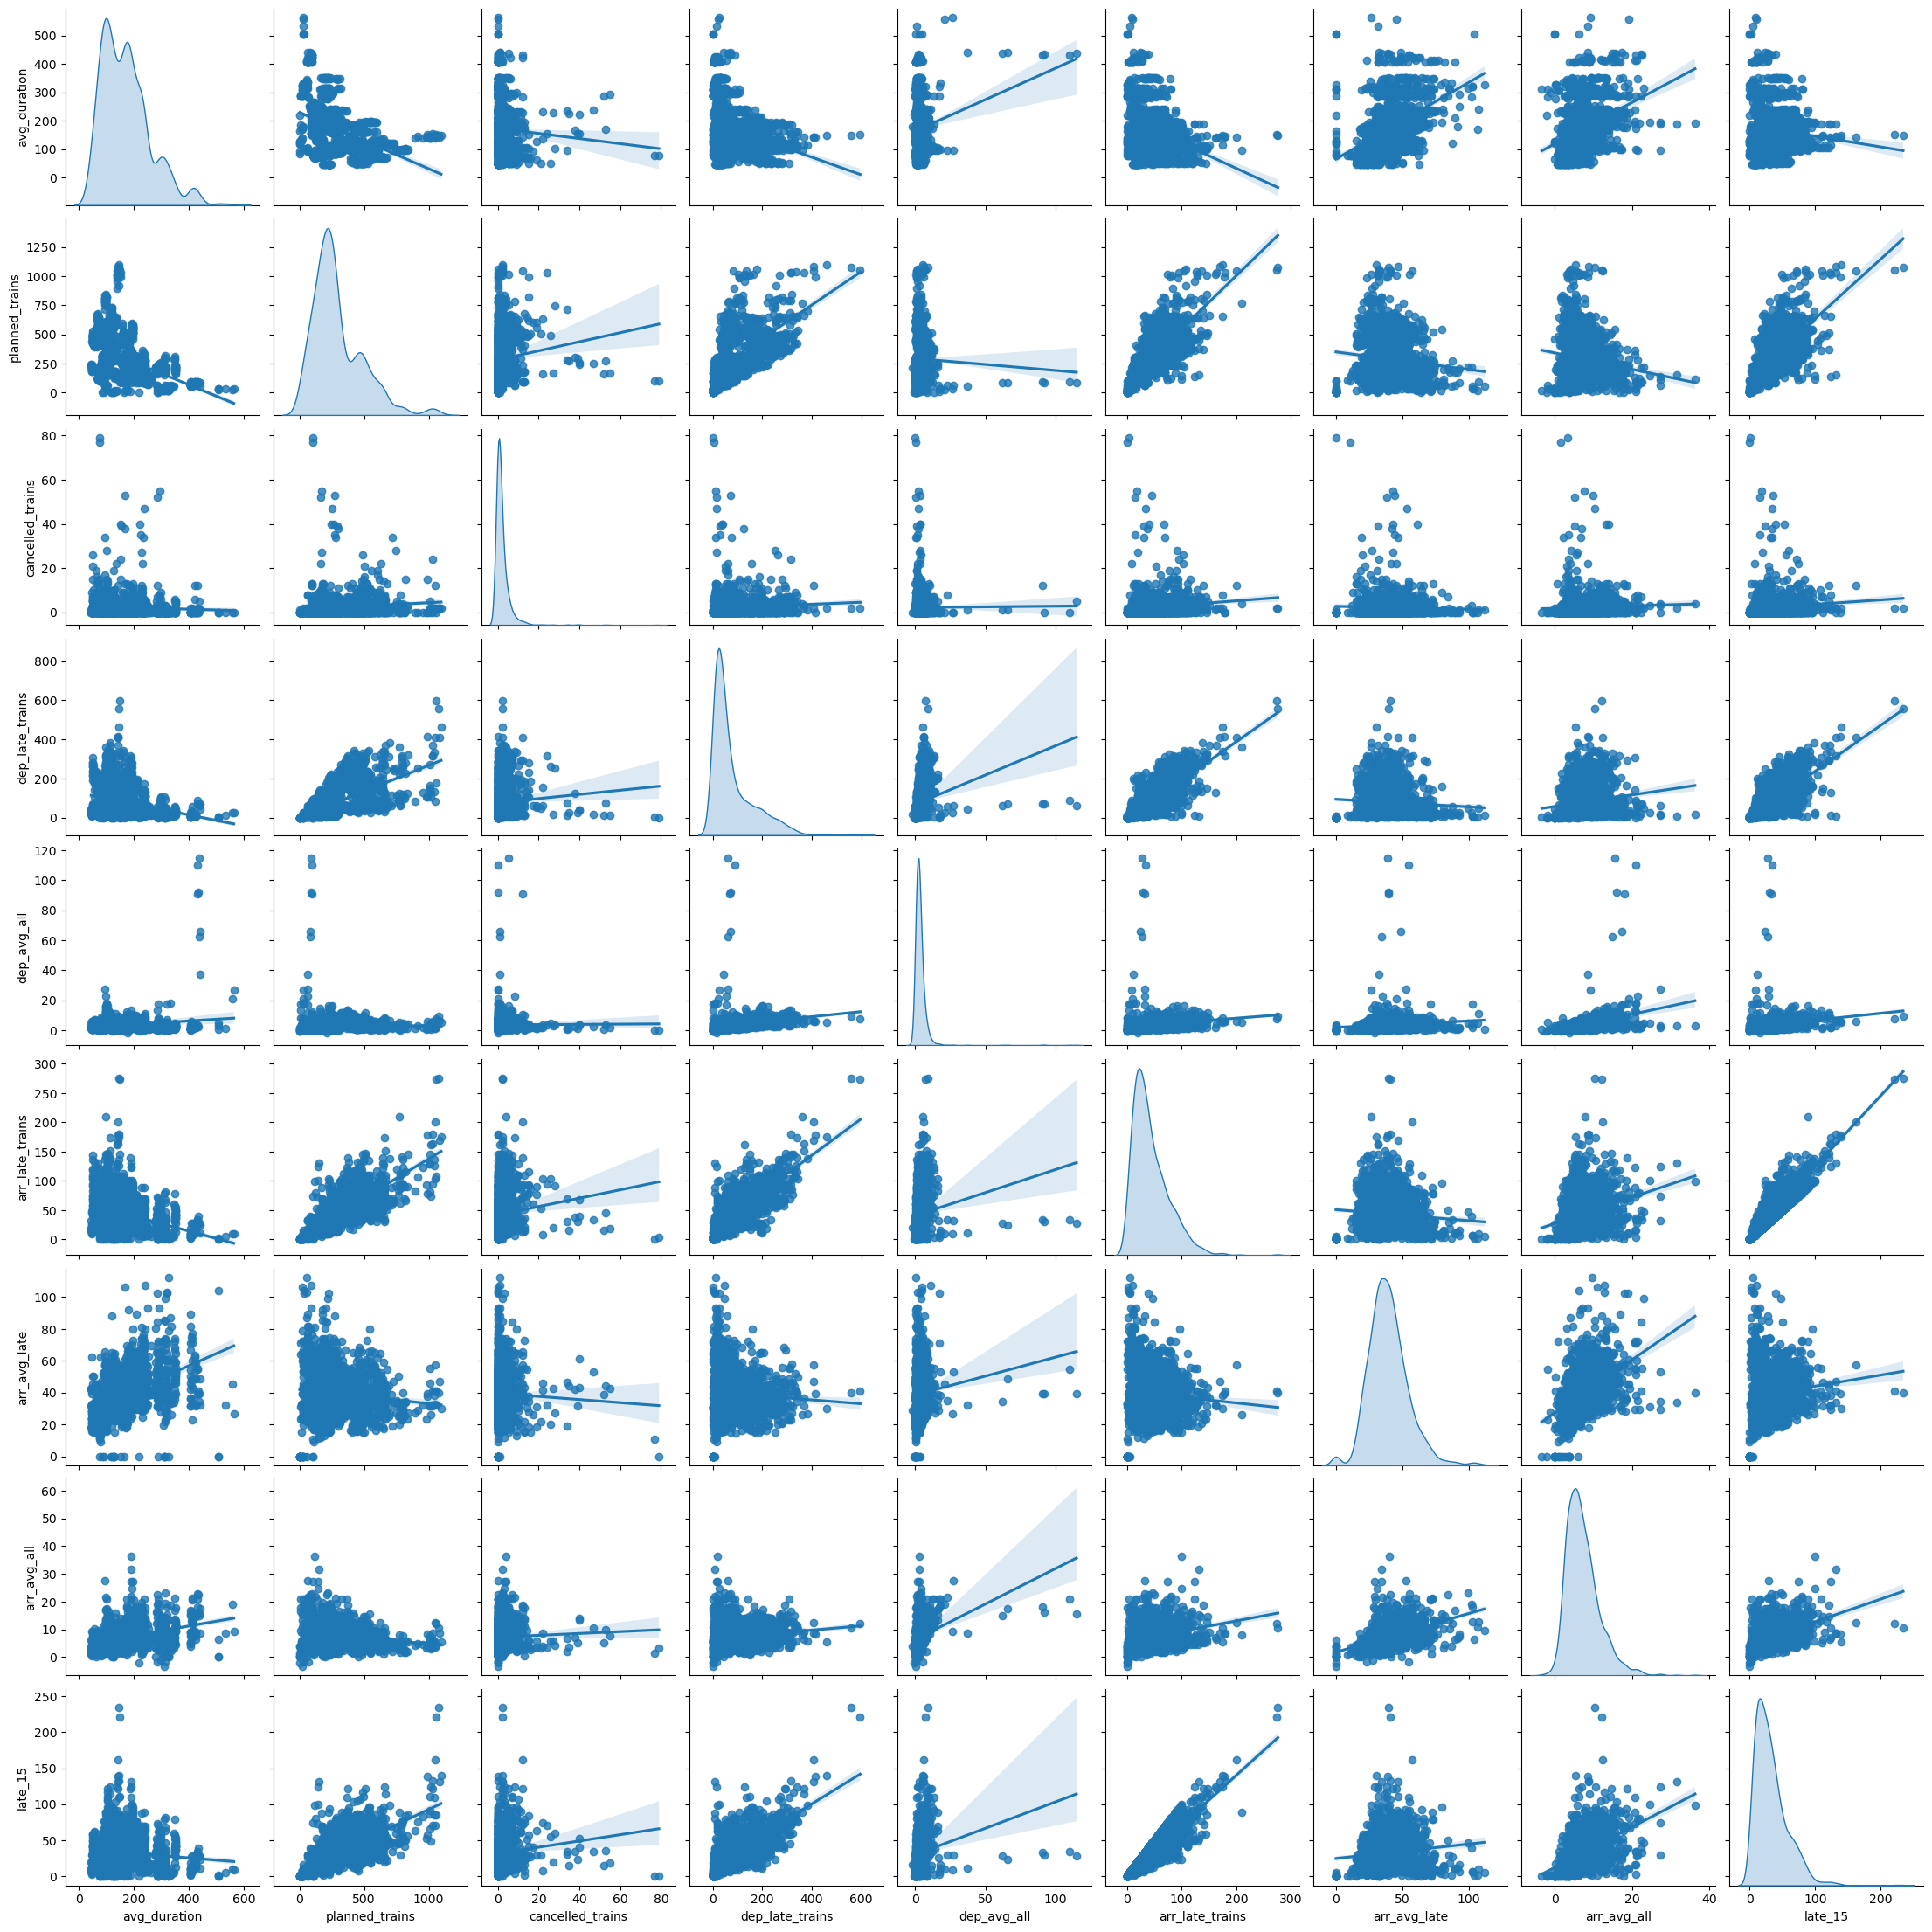

In [18]:
# On sélectionne les colonnes (index 1 à 3 et 5 à 9, car Python commence à 0)
cols = list(range(0, 4)) + list(range(5, 10))
subset = data_quanti.iloc[:, cols]

# Calcul de la matrice de corrélation
corr = data_temps_de_trajet_vs_retard.corr()

# Création de la carte de chaleur
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Matrice de corrélation")
sns.pairplot(subset, kind='reg', diag_kind='kde')
plt.show()

<div style="border:2px solid black; padding:10px;">
On constate que les causes de retard des trains ne sont pas liées aux durées de retard des trains. (en etudiant le dataset cause duree)
On constate que les trains qui partent en retard arrivent en retard (en etudiant le dataset data_temps_de_trajet_vs_retard).
<div/>

### 4. Les trains en retard rattrapent-ils leur retard ? l'augmentent-ils ? le conservent-ils ?

In [19]:
# Moyenne du retard ajouté aux trains déjà en retard au départ
tab=data['moy_retard_train_deja_retard']-data['dep_avg_late']
moy=0
for i in tab:
    moy+=i
moy=moy/1505
print(moy)

-0.8953102231111428


<div style="border:2px solid black; padding:10px;">
Sachant que le train est en retrad au départ, il arrive en moyenne avec 0,89 minutes de retard de plus qu'au départ. Ce n'est pas très concluant. Nous allons étudier la répartition de cette différence de retard entre le départ et l'arrivée, pour comprendre quelles proportions de trains rattrapent, conservent ou augmentent leur retard.
<div/>

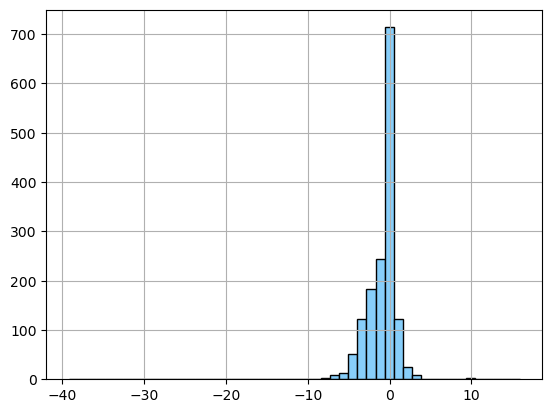

In [20]:
tab.hist(bins=50, color='lightskyblue', edgecolor='black')
plt.show()

<div style="border:2px solid black; padding:10px;">
On constate que la majorité des trains en retard au départ conservent leur retard (grand pic). 
Il y a moins de trains qui rattrapent leur retard (droite) que de trains qui augmentent leur retard (gauche).
 </div>

In [21]:
a = 10
train_accumul_retard = data[tab < -a]
print("Trains qui augmentent leur retard de plus de ", a, " minutes :")
for index, row in train_accumul_retard.iterrows():
    print(f"Alerte : {row['dep_station']} - {row['arr_station']} - {row['date']} ont augmenté leur retard au départ de {-(row['moy_retard_train_deja_retard']-row['dep_avg_late']):.2f} minutes.")

b = 5
train_accumul_retard = data[tab < -b]
print("Trains qui rattrapent plus de ", b, " minutes de retard :")
for index, row in train_accumul_retard.iterrows():
    print(f"{row['dep_station']} - {row['arr_station']} - {row['date']} ont rattrapé {-(row['moy_retard_train_deja_retard']-row['dep_avg_late']):.2f} minutes de retard.")

Trains qui augmentent leur retard de plus de  10  minutes :
Alerte : PARIS LYON - CHAMBERY CHALLES LES EAUX - 2025-02 ont augmenté leur retard au départ de 15.91 minutes.
Alerte : PARIS LYON - GRENOBLE - 2025-04 ont augmenté leur retard au départ de 39.19 minutes.
Alerte : ST MALO - PARIS MONTPARNASSE - 2025-04 ont augmenté leur retard au départ de 22.07 minutes.
Alerte : PARIS LYON - LAUSANNE - 2025-11 ont augmenté leur retard au départ de 36.29 minutes.
Alerte : PARIS LYON - DIJON VILLE - 2025-11 ont augmenté leur retard au départ de 20.58 minutes.
Trains qui rattrapent plus de  5  minutes de retard :
PARIS LYON - NIMES - 2025-01 ont rattrapé 6.60 minutes de retard.
PARIS LYON - MONTPELLIER - 2025-01 ont rattrapé 5.11 minutes de retard.
PARIS LYON - CHAMBERY CHALLES LES EAUX - 2025-02 ont rattrapé 15.91 minutes de retard.
PARIS MONTPARNASSE - ANGOULEME - 2025-02 ont rattrapé 5.78 minutes de retard.
PARIS MONTPARNASSE - POITIERS - 2025-02 ont rattrapé 5.32 minutes de retard.
PARIS MON

<div style="border:2px solid black; padding:10px;">
Attention, dans l'histogramme il y a quelques trains qui augmentent leur retard de plus de 10 minutes mais qui ne se voient pas.
 </div>

### 5. Le concurrence aérienne a t-elle un impact sur le nombre de trains en retard ?

### 6. Existe t-il une corrélation entre la date d'un trajet et la cause des retards ? 

# Réduction de dimension linéaire

## Qu'est ce qui pourrait, dans les variables qualitatives, expliquer le retard ? - MCA

Nos individus sont très déterminés par des variables qualitatives (Gare de départ, gare d'arrivée ...). Nous allons donc utiliser la MCA pour étudier les données.

Nous allons tenter de répondre à la question suivte : "Est-ce qu'on peut expliquer le retard 'un train en fonction de la date, du service, de la gare de départ et/ou de la gare d'arrivée ?"

Pour cela nous allons créer une variable qualitative prenant pour valeur 'Jamais', 'Rarement', 'Régulièrement', 'Souvent' en fonction de la proportion de retard sur une liaison et sur un mois.

In [22]:
proportion_retard = (data['arr_late_trains']+data['cancelled_trains']) / data['planned_trains']

bins = [-0.01, 0.05, 0.15, 0.40, 1.0]
labels = ['Jamais', 'Rarement', 'Régulièrement', 'Souvent']

data['retard'] = pd.cut(proportion_retard, bins=bins, labels=labels)

print(data['retard'].value_counts())

retard
Rarement         756
Régulièrement    685
Jamais            34
Souvent           30
Name: count, dtype: int64


In [23]:
df_mca=data.select_dtypes(include='category')
display(df_mca.head())

,date,service,dep_station,arr_station,retard
0,2025-01,International,GENEVE,PARIS LYON,Rarement
1,2025-01,International,ITALIE,PARIS LYON,Régulièrement
2,2025-01,National,BESANCON FRANCHE COMTE TGV,PARIS LYON,Rarement
3,2025-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,Régulièrement
4,2025-01,National,BREST,PARIS MONTPARNASSE,Rarement


<Figure size 1400x800 with 0 Axes>

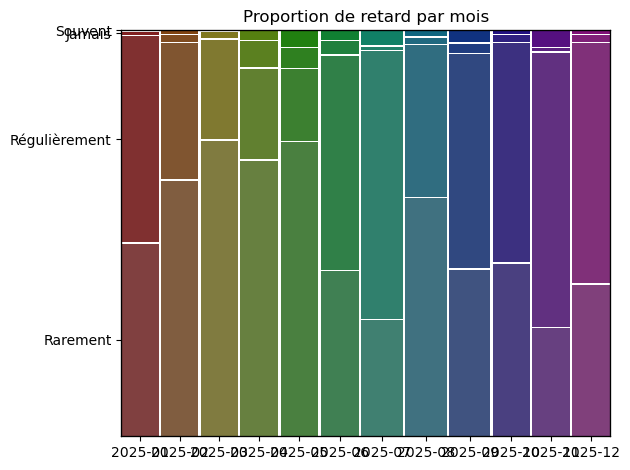

In [24]:
plt.figure(figsize=(14, 8))
mosaic(df_mca, ['date', 'retard'], 
       title='Proportion de retard par mois',
       labelizer=lambda k: "")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Le mois pour lequel il y a le plus de retard est le mois de juillet.

In [25]:
X = df_mca[['service', 'dep_station', 'arr_station']]

mca = prince.MCA(
    n_components=3,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)

mca = mca.fit(X)

mca.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,0.738,1.92%,1.92%
1,0.634,1.65%,3.58%
2,0.625,1.63%,5.21%


In [26]:
mca.column_contributions_.T.style.background_gradient(cmap='YlOrRd', axis=1).format('{:.0%}')

,service__International,service__National,dep_station__0,dep_station__AIX EN PROVENCE TGV,dep_station__ANGERS SAINT LAUD,dep_station__ANGOULEME,dep_station__ANNECY,dep_station__ARRAS,dep_station__AVIGNON TGV,dep_station__BARCELONA,dep_station__BELLEGARDE (AIN),dep_station__BESANCON FRANCHE COMTE TGV,dep_station__BORDEAUX ST JEAN,dep_station__BREST,dep_station__CHAMBERY CHALLES LES EAUX,dep_station__DIJON VILLE,dep_station__DOUAI,dep_station__DUNKERQUE,dep_station__FRANCFORT,dep_station__GENEVE,dep_station__GRENOBLE,dep_station__ITALIE,dep_station__LA ROCHELLE VILLE,dep_station__LAUSANNE,dep_station__LAVAL,dep_station__LE CREUSOT MONTCEAU MONTCHANIN,dep_station__LE MANS,dep_station__LILLE,dep_station__LYON PART DIEU,dep_station__MACON LOCHE,dep_station__MARNE LA VALLEE,dep_station__MARSEILLE ST CHARLES,dep_station__METZ,dep_station__MONTPELLIER,dep_station__MULHOUSE VILLE,dep_station__NANCY,dep_station__NANTES,dep_station__NICE VILLE,dep_station__NIMES,dep_station__PARIS EST,dep_station__PARIS LYON,dep_station__PARIS MONTPARNASSE,dep_station__PARIS NORD,dep_station__PERPIGNAN,dep_station__POITIERS,dep_station__QUIMPER,dep_station__REIMS,dep_station__RENNES,dep_station__SAINT ETIENNE CHATEAUCREUX,dep_station__ST MALO,dep_station__ST PIERRE DES CORPS,dep_station__STRASBOURG,dep_station__STUTTGART,dep_station__TOULON,dep_station__TOULOUSE MATABIAU,dep_station__TOURCOING,dep_station__TOURS,dep_station__VALENCE ALIXAN TGV,dep_station__VANNES,dep_station__ZURICH,arr_station__0,arr_station__AIX EN PROVENCE TGV,arr_station__ANGERS SAINT LAUD,arr_station__ANGOULEME,arr_station__ANNECY,arr_station__ARRAS,arr_station__AVIGNON TGV,arr_station__BARCELONA,arr_station__BELLEGARDE (AIN),arr_station__BESANCON FRANCHE COMTE TGV,arr_station__BORDEAUX ST JEAN,arr_station__BREST,arr_station__CHAMBERY CHALLES LES EAUX,arr_station__DIJON VILLE,arr_station__DOUAI,arr_station__DUNKERQUE,arr_station__FRANCFORT,arr_station__GENEVE,arr_station__GRENOBLE,arr_station__ITALIE,arr_station__LA ROCHELLE VILLE,arr_station__LAUSANNE,arr_station__LAVAL,arr_station__LE CREUSOT MONTCEAU MONTCHANIN,arr_station__LE MANS,arr_station__LILLE,arr_station__LYON PART DIEU,arr_station__MACON LOCHE,arr_station__MARNE LA VALLEE,arr_station__MARSEILLE ST CHARLES,arr_station__METZ,arr_station__MONTPELLIER,arr_station__MULHOUSE VILLE,arr_station__NANCY,arr_station__NANTES,arr_station__NICE VILLE,arr_station__NIMES,arr_station__PARIS EST,arr_station__PARIS LYON,arr_station__PARIS MONTPARNASSE,arr_station__PARIS NORD,arr_station__PERPIGNAN,arr_station__POITIERS,arr_station__QUIMPER,arr_station__REIMS,arr_station__RENNES,arr_station__SAINT ETIENNE CHATEAUCREUX,arr_station__ST MALO,arr_station__ST PIERRE DES CORPS,arr_station__STRASBOURG,arr_station__STUTTGART,arr_station__TOULON,arr_station__TOULOUSE MATABIAU,arr_station__TOURCOING,arr_station__TOURS,arr_station__VALENCE ALIXAN TGV,arr_station__VANNES,arr_station__ZURICH
0,24%,4%,0%,0%,0%,1%,0%,0%,0%,1%,0%,0%,1%,1%,0%,0%,0%,0%,3%,2%,0%,2%,1%,2%,0%,0%,0%,0%,1%,0%,0%,1%,1%,0%,0%,0%,0%,0%,0%,2%,1%,2%,0%,0%,0%,0%,0%,1%,0%,1%,0%,0%,3%,0%,0%,0%,0%,0%,0%,2%,0%,0%,0%,0%,0%,0%,0%,1%,0%,0%,0%,0%,0%,0%,0%,0%,2%,1%,0%,1%,0%,1%,0%,0%,1%,1%,1%,0%,1%,0%,0%,0%,0%,0%,0%,0%,0%,6%,6%,7%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,2%,0%,0%,1%,0%,0%,0%,1%
1,0%,0%,0%,0%,0%,0%,0%,1%,0%,1%,1%,1%,1%,0%,1%,0%,2%,1%,1%,0%,0%,0%,0%,0%,0%,1%,0%,1%,0%,0%,0%,0%,1%,0%,0%,1%,1%,1%,0%,15%,1%,7%,1%,0%,1%,0%,1%,0%,0%,0%,0%,0%,0%,0%,0%,1%,0%,0%,0%,0%,0%,0%,1%,1%,0%,0%,0%,0%,0%,0%,2%,0%,0%,0%,0%,1%,3%,0%,0%,0%,0%,0%,0%,0%,1%,0%,0%,0%,0%,1%,3%,0%,0%,2%,1%,0%,0%,2%,9%,4%,6%,0%,0%,1%,3%,0%,0%,0%,0%,3%,3%,0%,1%,0%,0%,0%,0%,0%
2,0%,0%,0%,1%,0%,0%,1%,1%,1%,0%,1%,1%,1%,0%,0%,1%,4%,3%,1%,0%,0%,1%,0%,0%,0%,0%,0%,2%,0%,0%,1%,1%,0%,0%,1%,0%,1%,1%,0%,4%,11%,1%,2%,1%,1%,0%,0%,0%,0%,0%,0%,1%,1%,1%,0%,0%,0%,1%,0%,1%,1%,0%,0%,0%,0%,1%,0%,0%,1%,1%,0%,0%,1%,0%,0%,1%,1%,0%,0%,1%,0%,0%,0%,0%,0%,0%,1%,1%,1%,1%,1%,0%,1%,1%,0%,1%,0%,3%,11%,3%,9%,0%,0%,0%,0%,0%,1%,0%,0%,1%,0%,1%,0%,1%,0%,0%,0%,0%


On peut voir que c'est principalement la variable service_International qui contribut à l'axe 0, la variable dep_station_PARIS qui contribut à l'axe 1 et les variables arr_station_PARIS LYON et dep_station_PARIS LYON qui contribuent à l'axe 2.

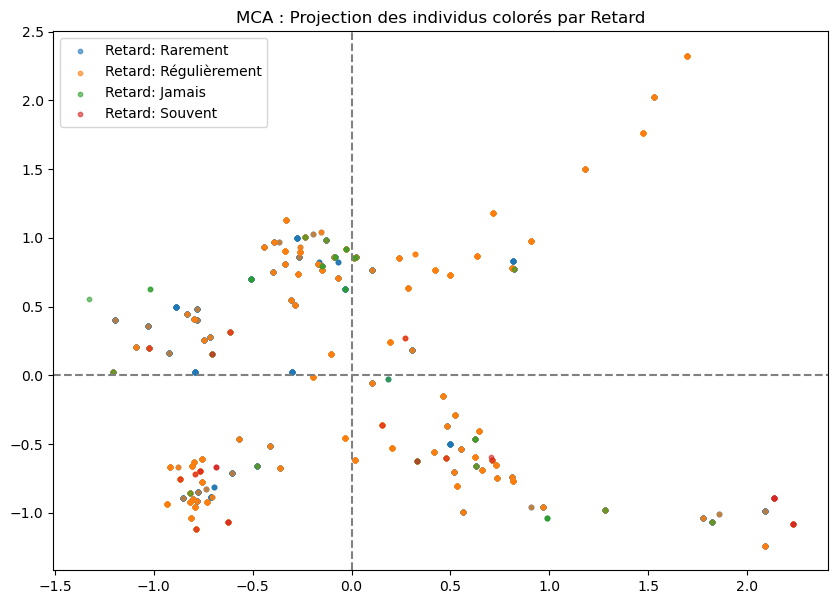

In [27]:
# Obtenir les coordonnées des lignes (individus)
row_coordinates = mca.row_coordinates(X)

# Tracer le graphique
plt.figure(figsize=(10, 7))
for val in df_mca['retard'].unique():
    mask = df_mca['retard'] == val
    plt.scatter(
        row_coordinates.loc[mask, 1], 
        row_coordinates.loc[mask, 2], 
        label=f"Retard: {val}",
        alpha=0.6,
        s=10
    )

plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.title("MCA : Projection des individus colorés par Retard")
plt.legend()
plt.show()

On remarque que les resultats de cette analyse ne sont pas interprétables.

**Demander quoi faire aux profs avec ça !**

## Qu'est ce qui pourrait, dans les variables qualitatives, expliquer le retard ? - ACP

Dans cette partie on va essayer d'expliquer la proportion de retard d'une autre manière. Pour se faire nous allons construire un plan ACP avec les variables quantitatives (hors pourcentages) et essayer de trouver des éléments qui expliqueraient le retard.

In [28]:
var_pca=["avg_duration", "planned_trains", "cancelled_trains", "dep_late_trains", "dep_avg_late", "dep_avg_all", "arr_avg_late", "arr_avg_all", "late_15", "late_15_air", "late_30", "late_60"]
df_pca = data[var_pca]
display(df_pca.head())

,avg_duration,planned_trains,cancelled_trains,dep_late_trains,dep_avg_late,dep_avg_all,arr_avg_late,arr_avg_all,late_15,late_15_air,late_30,late_60
0,193,238,1,216,3.182485,2.979606,42.776316,4.399015,19,42.776316,0,13
1,535,30,0,14,2.713095,1.366667,31.940000,8.500556,5,31.940000,0,1
2,133,183,0,30,17.588889,2.555373,52.936111,6.397359,20,60.764167,0,14
3,145,1029,0,317,18.564090,5.589828,40.713704,8.774603,132,50.812500,0,69
4,232,294,7,20,11.966667,0.835714,37.223889,4.704413,30,37.223889,0,13


In [29]:
pca = prince.PCA(
    n_components=10,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)

pca = pca.fit(df_pca)

display(pca.eigenvalues_summary)

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,3.819,31.82%,31.82%
1,2.697,22.47%,54.29%
2,1.360,11.34%,65.63%
3,1.057,8.81%,74.44%
4,0.991,8.26%,82.70%
5,0.611,5.09%,87.79%
6,0.569,4.74%,92.53%
7,0.458,3.81%,96.34%
8,0.162,1.35%,97.69%


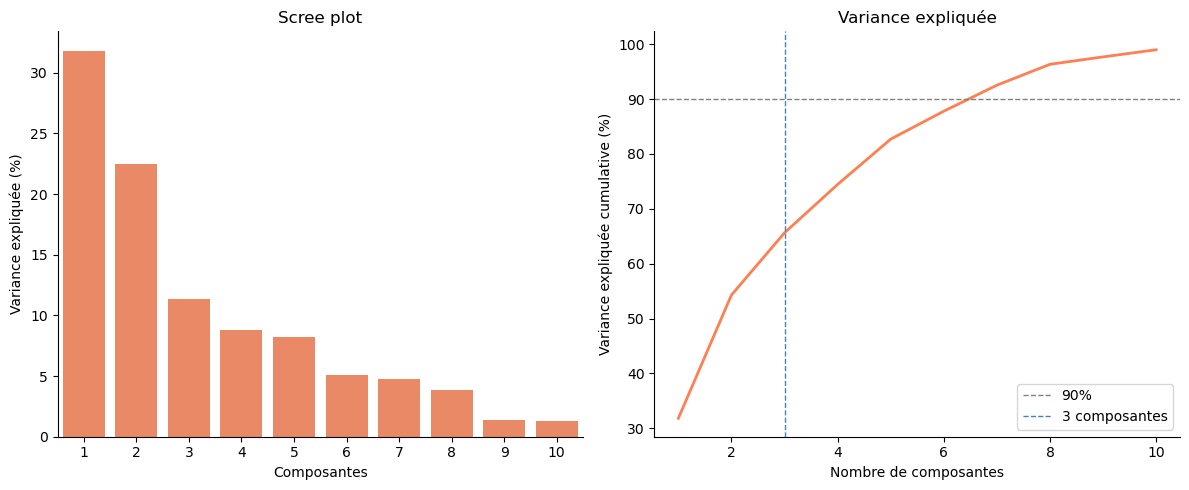

Variance expliquée par les 3 premières componsantes : 65.63%


In [38]:
explained_variance_ratio = pca.eigenvalues_summary['% of variance'].str.replace('%', '').astype(float)
n_bars = 10

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scree plot
sns.barplot(x=np.arange(1, n_bars + 1), y=explained_variance_ratio[:n_bars],
            color="coral", ax=axes[0])
axes[0].set_xlabel("Composantes")
axes[0].set_ylabel("Variance expliquée (%)")
axes[0].set_title("Scree plot")
axes[0].spines[["top", "right"]].set_visible(False)

# Cumulative explained variance
cumvar = np.cumsum(explained_variance_ratio)
axes[1].plot(np.arange(1, len(cumvar) + 1), cumvar, color="coral", linewidth=2)
axes[1].axhline(90, color="gray", linestyle="--", linewidth=1, label="90%")
axes[1].axvline(3, color="steelblue", linestyle="--", linewidth=1, label="3 composantes")
axes[1].set_xlabel("Nombre de composantes")
axes[1].set_ylabel("Variance expliquée cumulative (%)")
axes[1].set_title("Variance expliquée")
axes[1].legend()
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Variance expliquée par les 3 premières componsantes : {cumvar[2]:.2f}%")

On remarque que la variance est mal expliquée par les premières composantes principales. On va choisir de représenter les 3 premières, tout en sachant qu'il faudra mettre en perspectives les resultats vu que seulement 65.63% de la variance sera expliquée.

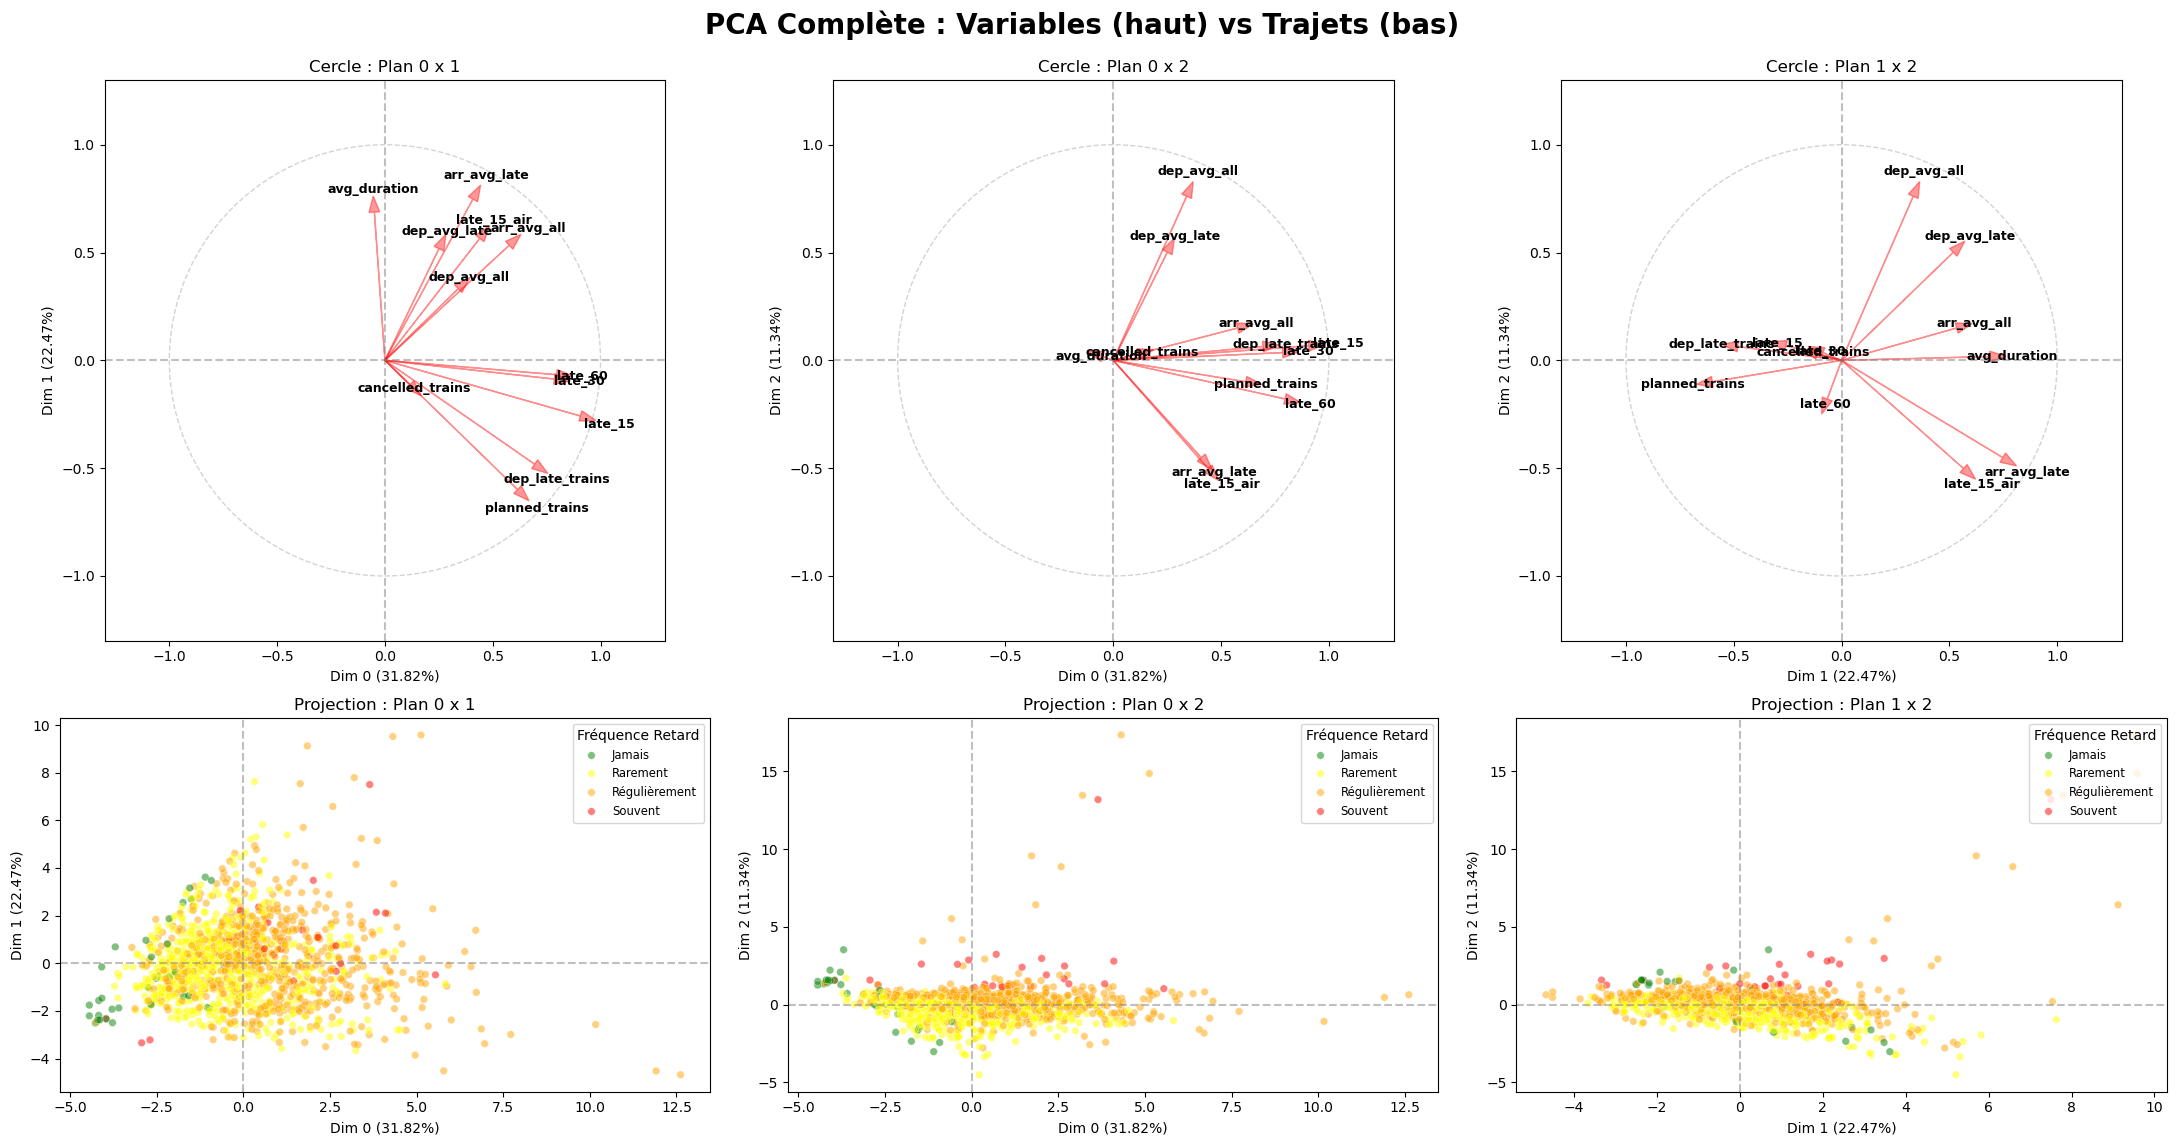

In [19]:
var_correlations = pca.column_correlations
coords = pca.row_coordinates(df_pca)
retard_col = data.loc[df_pca.index, 'retard']
pairs = [(0, 1), (0, 2), (1, 2)]
palette_retard = {'Jamais':'green', 'Rarement':'yellow', 'Régulièrement':'orange', 'Souvent': 'red'}

fig, axes = plt.subplots(2, 3, figsize=(22, 12), gridspec_kw={'height_ratios': [1.5, 1]})

for i, (dim_x, dim_y) in enumerate(pairs):
    ax_circle = axes[0, i]
    circle = plt.Circle((0,0), 1, color='lightgrey', fill=False, linestyle='--')
    ax_circle.add_artist(circle)
    
    for col in var_correlations.index:
        x = var_correlations.loc[col, dim_x]
        y = var_correlations.loc[col, dim_y]
        ax_circle.arrow(0, 0, x, y, color='r', alpha=0.4, head_width=0.05)
        ax_circle.text(x*1.15, y*1.15, col, color='black', ha='center', va='center', fontsize=9, fontweight='bold')

    ax_circle.set_xlim(-1.3, 1.3)
    ax_circle.set_ylim(-1.3, 1.3)
    ax_circle.axhline(0, color='grey', linestyle='--', alpha=0.5)
    ax_circle.axvline(0, color='grey', linestyle='--', alpha=0.5)
    
    var_x = pca.eigenvalues_summary.loc[dim_x, '% of variance']
    var_y = pca.eigenvalues_summary.loc[dim_y, '% of variance']
    
    ax_circle.set_title(f"Cercle : Plan {dim_x} x {dim_y}")
    ax_circle.set_xlabel(f"Dim {dim_x} ({var_x})")
    ax_circle.set_ylabel(f"Dim {dim_y} ({var_y})")
    ax_circle.set_aspect('equal')

    ax_proj = axes[1, i]
    sns.scatterplot(
        x=coords[dim_x], 
        y=coords[dim_y], 
        hue=retard_col, 
        palette=palette_retard,
        hue_order=['Jamais', 'Rarement', 'Régulièrement', 'Souvent'],
        alpha=0.5, 
        s=30, 
        ax=ax_proj
    )
    ax_proj.set_title(f"Projection : Plan {dim_x} x {dim_y}")
    ax_proj.set_xlabel(f"Dim {dim_x} ({var_x})")
    ax_proj.set_ylabel(f"Dim {dim_y} ({var_y})")
    ax_proj.axhline(0, color='grey', linestyle='--', alpha=0.5)
    ax_proj.axvline(0, color='grey', linestyle='--', alpha=0.5)
    ax_proj.legend(title='Fréquence Retard', loc='upper right', fontsize='small')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle("PCA Complète : Variables (haut) vs Trajets (bas)", fontsize=20, fontweight='bold')
plt.show()

**Faire interprétation, j'ai le cerveau embrummé**

# Méthodes de clustering

### Affichage des fréquences de retard dans un plan construit par MFA grâce aux catégories Performance, Causes et Contexte définit ci dessous

In [63]:
groups = {
    'Performance': [
        'avg_duration', 'planned_trains', 'cancelled_trains', 'dep_late_trains', 
        'dep_avg_late', 'arr_late_trains', 'arr_avg_late'
    ],
    'Causes': [
        'pct_external', 'pct_infra', 'pct_traffic', 
        'pct_rolling', 'pct_station', 'pct_passengers'
    ],
    'Contexte': [
        'service', 'dep_station', 'arr_station'
    ]
}

cols_num = groups['Performance'] + groups['Causes']
cols_quali = groups['Contexte']

In [64]:
contexte_dummies = pd.get_dummies(data[groups['Contexte']])
new_contexte_cols = contexte_dummies.columns.tolist()

groups_numeric = {
    'Performance': groups['Performance'],
    'Causes': groups['Causes'],
    'Contexte': new_contexte_cols
}

df_mfa_numeric = pd.concat([data[groups['Performance'] + groups['Causes']], contexte_dummies], axis=1)

mfa = prince.MFA(n_components=10)
mfa = mfa.fit(df_mfa_numeric, groups=groups_numeric)
mfa.eigenvalues_summary

ValueError: Not all columns in "Causes" group are of the same type

In [65]:
explained_variance_ratio = mfa.eigenvalues_summary['% of variance'].str.replace('%', '').astype(float)
n_bars = 10

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scree plot
sns.barplot(x=np.arange(1, n_bars + 1), y=explained_variance_ratio[:n_bars],
            color="coral", ax=axes[0])
axes[0].set_xlabel("Composantes")
axes[0].set_ylabel("Variance expliquée (%)")
axes[0].set_title("Scree plot")
axes[0].spines[["top", "right"]].set_visible(False)

# Cumulative explained variance
cumvar = np.cumsum(explained_variance_ratio)
axes[1].plot(np.arange(1, len(cumvar) + 1), cumvar, color="coral", linewidth=2)
axes[1].axhline(90, color="gray", linestyle="--", linewidth=1, label="90%")
axes[1].axvline(3, color="steelblue", linestyle="--", linewidth=1, label="3 composantes")
axes[1].set_xlabel("Nombre de composantes")
axes[1].set_ylabel("Variance expliquée cumulative (%)")
axes[1].set_title("Variance expliquée")
axes[1].legend()
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Variance expliquée par les 3 premières componsantes : {cumvar[2]:.2f}%")

AttributeError: 'MFA' object has no attribute 'svd_'

In [66]:
col_contribs = mfa.column_contributions_

group_results = {}

for group_name, original_cols in groups.items():
    mask = col_contribs.index.to_series().apply(
        lambda x: any(str(c) in str(x) for c in original_cols)
    )
    group_results[group_name] = col_contribs[mask].sum()
df_group_contribs = pd.DataFrame(group_results).T

df_group_contribs.iloc[:, :3].plot(kind='bar', figsize=(12, 6), width=0.8)
plt.title("Importance des groupes de variables (MFA)", fontsize=14)
plt.ylabel("Contribution cumulée")
plt.xticks(rotation=0)
plt.legend(["Dimension 0", "Dimension 1", "Dimension 2"])
plt.grid(axis='y', alpha=0.3)
plt.show()

AttributeError: 'MFA' object has no attribute 'column_coordinates_'

AttributeError: 'MFA' object has no attribute 'column_weight_'

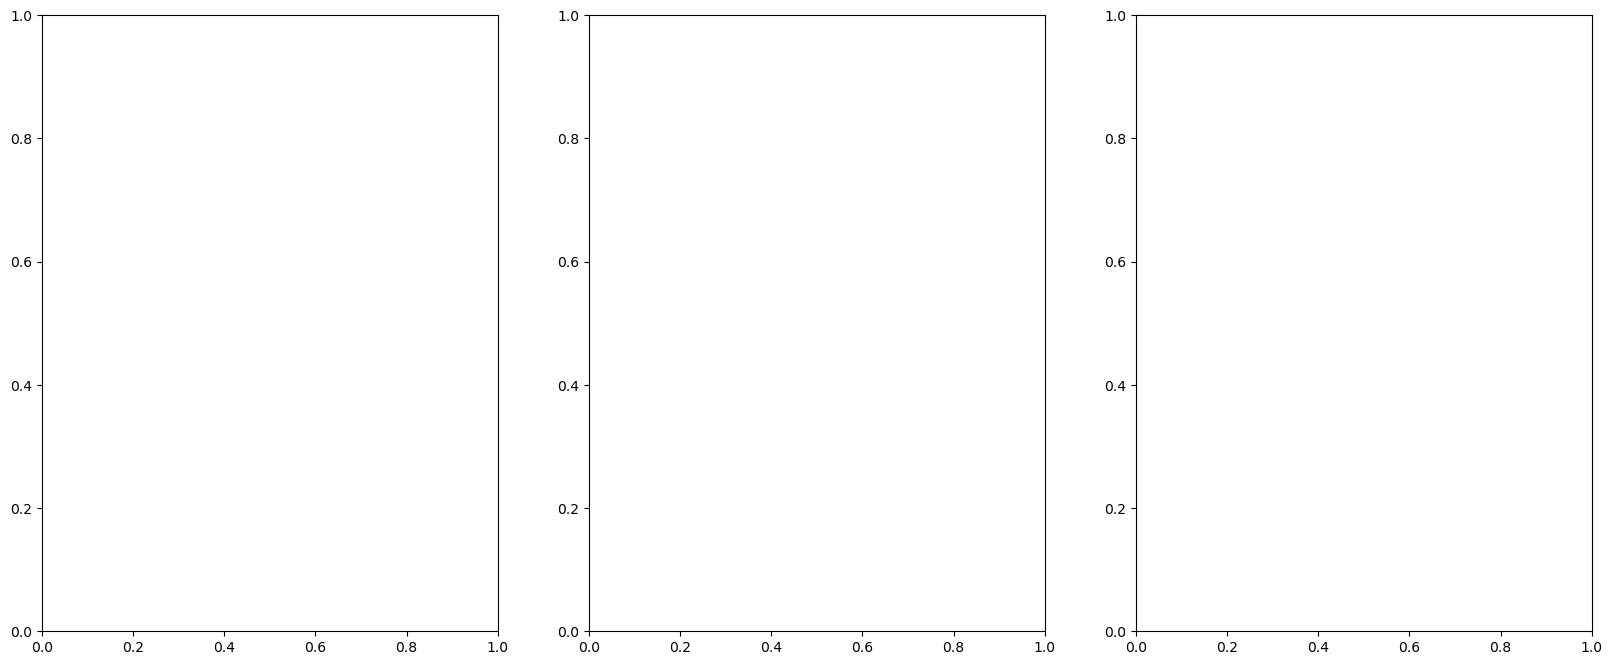

In [67]:
cols_quali = ['service', 'dep_station', 'arr_station']
pairs = [(0, 1), (0, 2), (1, 2)]
cols_num = groups['Performance'] + groups['Causes']
palette_retard = {'Jamais':'green', 'Rarement':'yellow', 'Régulièrement':'orange', 'Souvent': 'red'}

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
coords=mfa.row_coordinates(df_mfa_numeric)

for i, (dim_x, dim_y) in enumerate(pairs):
    ax_proj = axes[i]
    sns.scatterplot(
        x=coords[dim_x], 
        y=coords[dim_y], 
        hue=retard_col, 
        palette=palette_retard,
        hue_order=['Jamais', 'Rarement', 'Régulièrement', 'Souvent'],
        alpha=0.5, 
        s=30, 
        ax=ax_proj
    )
    ax_proj.set_title(f"Projection : Plan {dim_x} x {dim_y}")
    ax_proj.set_xlabel(f"Dim {dim_x} ({var_x})")
    ax_proj.set_ylabel(f"Dim {dim_y} ({var_y})")
    ax_proj.axhline(0, color='grey', linestyle='--', alpha=0.5)
    ax_proj.axvline(0, color='grey', linestyle='--', alpha=0.5)
    ax_proj.legend(title='Fréquence Retard', loc='upper right', fontsize='small')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle("Retads des trajets dans le plan MFA", fontsize=20, fontweight='bold')
plt.show()